# Credit Card Fraud Detection under Extreme Class Imbalance
## Capstone 20.1 — Initial Report, Exploratory Data Analysis and Baseline Model
**Author:** Asit Kar

**Research question:** Can a supervised machine learning model — trained on anonymised credit card transaction features and explicitly designed to handle extreme class imbalance (~0.17% fraud) — accurately distinguish fraudulent from legitimate transactions while minimising the total business cost of missed fraud (false negatives) and blocked legitimate customers (false positives)?

**Dataset:** ULB Machine Learning Group, *Credit Card Fraud Detection* (Kaggle) — 284,807 European card transactions over two days in September 2013; `Time`, `Amount`, 28 PCA components `V1`–`V28`, target `Class` (1 = fraud).

### Contents
1. Setup and data loading
2. Data understanding
3. Data cleaning (missing values, duplicates, types)
4. Outlier analysis
5. Exploratory data analysis
6. Feature engineering
7. Baseline model, evaluation metric and cost-based threshold
8. Summary of findings and next steps

## 1. Setup and data loading

In [1]:
# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

# Modelling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_recall_curve,
                             PrecisionRecallDisplay, ConfusionMatrixDisplay, confusion_matrix,
                             fbeta_score, precision_score, recall_score)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
IMG_DIR = '../images'
os.makedirs(IMG_DIR, exist_ok=True)

# Palette used throughout: blue = legitimate, red = fraud
CLASS_COLORS = {'Legitimate': '#4C72B0', 'Fraud': '#C44E52'}

In [2]:
# The CSV (~100 MB) is too large for the repo; load locally if present, else from a public mirror
LOCAL_PATH = '../data/creditcard.csv'
MIRROR_URL = ('https://raw.githubusercontent.com/nsethi31/'
              'Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv')
source = LOCAL_PATH if os.path.exists(LOCAL_PATH) else MIRROR_URL

transactions_raw = pd.read_csv(source)
print(f'Rows: {transactions_raw.shape[0]:,} | Columns: {transactions_raw.shape[1]}')
transactions_raw.head()

Rows: 284,807 | Columns: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Data understanding

In [3]:
# Data types and memory footprint (compact view instead of a 31-line .info())
dtype_summary = transactions_raw.dtypes.value_counts().rename('columns').to_frame()
print(f'Memory: {transactions_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')
dtype_summary

Memory: 70.6 MB


,columns
float64,30
int64,1


In [4]:
# Summary statistics for the interpretable columns
transactions_raw[['Time', 'Amount', 'Class']].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.86,47488.15,0.0,54201.5,84692.0,139320.50,172792.00
Amount,284807.0,88.35,250.12,0.0,5.6,22.0,77.16,25691.16
Class,284807.0,0.00,0.04,0.0,0.0,0.0,0.00,1.00


In [5]:
# The PCA components should be centred on zero with decreasing variance
pca_cols = [f'V{i}' for i in range(1, 29)]
transactions_raw[pca_cols].agg(['mean', 'std']).T.round(3).head(8)

,mean,std
V1,0.0,1.959
V2,-0.0,1.651
V3,-0.0,1.516
V4,0.0,1.416
V5,0.0,1.380
V6,0.0,1.332
V7,-0.0,1.237
V8,0.0,1.194


**Observations**
- All 31 columns are numeric; `Class` is the binary target.
- `V1`–`V28` are PCA outputs (mean ≈ 0, variance decreasing from V1 to V28); their original meaning is confidential, so interpretation relies on their statistical behaviour.
- `Time` is seconds elapsed since the first transaction (0 – 172,792 s ≈ 48 hours); `Amount` is the transaction value in euros and is **not** scaled.

## 3. Data cleaning

In [6]:
transactions = transactions_raw.copy()

# 3.1 Missing values
print('Missing values in dataset:', transactions.isna().sum().sum())

# 3.2 Duplicate rows (identical in every column, including Time)
dup_mask = transactions.duplicated()
print(f'Duplicate rows: {dup_mask.sum():,}')
print('Class mix of duplicates:', transactions.loc[dup_mask, 'Class'].value_counts().to_dict())

Missing values in dataset: 0


Duplicate rows: 1,081
Class mix of duplicates: {0: 1062, 1: 19}


No values are missing, so imputation is not required. There are **1,081 exact duplicates** (same timestamp, amount and all 28 components) — almost certainly double-logged records. Keeping them would leak identical rows across train/test splits and overweight those transactions, so they are removed. This drops 19 fraud rows (492 → 473).

In [7]:
transactions = transactions.drop_duplicates().reset_index(drop=True)
transactions['Class'] = transactions['Class'].astype(int)

fraud_rate = transactions['Class'].mean()
print(f'Rows after de-duplication: {len(transactions):,}')
print(f'Fraud cases: {transactions["Class"].sum():,} ({fraud_rate:.3%})')

Rows after de-duplication: 283,726
Fraud cases: 473 (0.167%)


In [8]:
# Validity checks: no negative amounts or times
print('Negative Amount rows:', (transactions['Amount'] < 0).sum())
print('Negative Time rows:', (transactions['Time'] < 0).sum())
print('Zero-amount transactions:', (transactions['Amount'] == 0).sum(),
      '| of which fraud:', transactions.loc[transactions['Amount'] == 0, 'Class'].sum())

Negative Amount rows: 0
Negative Time rows: 0
Zero-amount transactions: 1808 | of which fraud: 25


Zero-value transactions are kept: they are valid card-verification events, and a small number are fraudulent (fraudsters often test stolen cards with tiny or zero amounts).

## 4. Outlier analysis

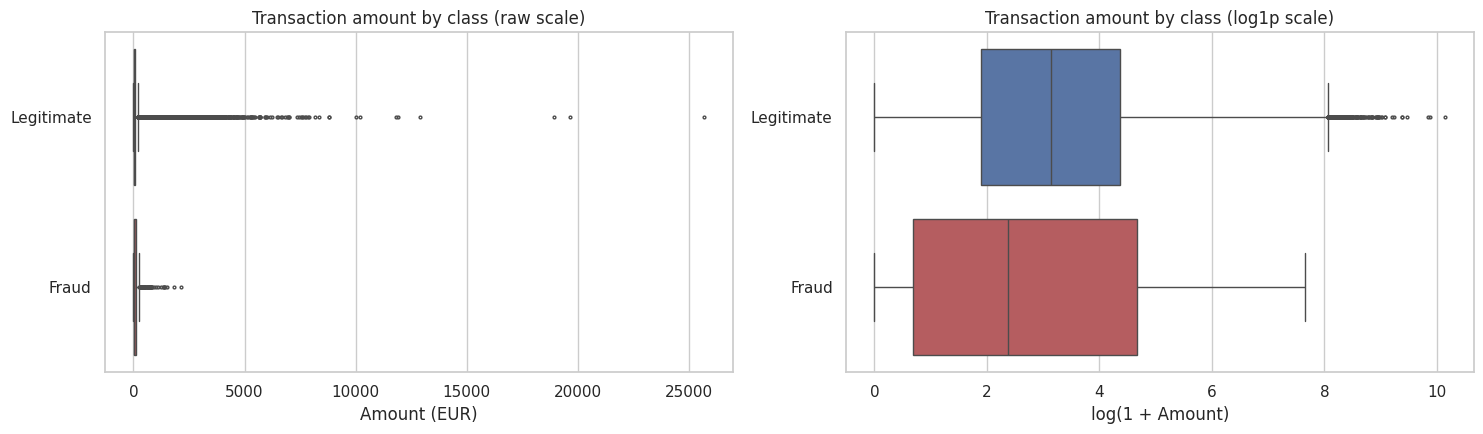

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.boxplot(data=transactions, x='Amount', y=transactions['Class'].map({0: 'Legitimate', 1: 'Fraud'}),
            palette=CLASS_COLORS, ax=axes[0], fliersize=2)
axes[0].set_title('Transaction amount by class (raw scale)')
axes[0].set_xlabel('Amount (EUR)')
axes[0].set_ylabel('')

sns.boxplot(data=transactions, x=np.log1p(transactions['Amount']),
            y=transactions['Class'].map({0: 'Legitimate', 1: 'Fraud'}),
            palette=CLASS_COLORS, ax=axes[1], fliersize=2)
axes[1].set_title('Transaction amount by class (log1p scale)')
axes[1].set_xlabel('log(1 + Amount)')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/amount_outliers.png', bbox_inches='tight')
plt.show()

In [10]:
# IQR-rule outlier counts per feature, and how much more common fraud is among the outliers
def iqr_flag(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)

outlier_rows = []
for col in pca_cols + ['Amount']:
    flag = iqr_flag(transactions[col])
    outlier_rows.append({'feature': col,
                         'outlier_share': flag.mean(),
                         'fraud_rate_in_outliers': transactions.loc[flag, 'Class'].mean()})

outlier_summary = (pd.DataFrame(outlier_rows).set_index('feature')
                   .assign(lift_vs_base=lambda d: d['fraud_rate_in_outliers'] / fraud_rate)
                   .sort_values('lift_vs_base', ascending=False))
outlier_summary.head(10).style.format({'outlier_share': '{:.2%}', 'fraud_rate_in_outliers': '{:.2%}',
                                       'lift_vs_base': '{:.1f}x'})

,outlier_share,fraud_rate_in_outliers,lift_vs_base
feature,,,
V11,0.26%,37.55%,225.2x
V3,1.17%,8.86%,53.2x
V17,2.59%,5.15%,30.9x
V16,2.88%,4.07%,24.4x
V10,3.29%,4.07%,24.4x
V7,3.12%,3.20%,19.2x
V18,2.63%,2.93%,17.6x
V14,4.96%,2.92%,17.5x
V4,3.91%,2.70%,16.2x


In [11]:
# Share of all fraud cases that are an IQR outlier on at least one of the top-5 features
top_outlier_feats = outlier_summary.head(5).index
any_outlier = np.column_stack([iqr_flag(transactions[c]) for c in top_outlier_feats]).any(axis=1)
print(f'Top-5 outlier features: {list(top_outlier_feats)}')
print(f'Transactions flagged: {any_outlier.mean():.2%} | '
      f'fraud captured: {transactions.loc[any_outlier, "Class"].sum() / transactions["Class"].sum():.1%}')

Top-5 outlier features: ['V11', 'V3', 'V17', 'V16', 'V10']
Transactions flagged: 8.19% | fraud captured: 88.6%


**Outlier findings**
- Every PCA component has statistical outliers, and `Amount` is heavily right-skewed (median ≈ €22, max ≈ €25,700).
- Critically, **the outliers *are* the signal**: fraud is ~24–225× more common than the base rate among IQR outliers on V11, V3, V17, V16 and V10 (and ~15–18× on V14, V4, V12). Transactions that are an outlier on any of the top-5 features make up only **8.2%** of rows but contain **88.6%** of all fraud.
- Removing outliers would therefore delete most of the fraud cases. The decision is to **keep all outliers** and handle scale with standardisation and a log transform of `Amount`, rather than capping or removing.

## 5. Exploratory data analysis
### 5.1 Class imbalance

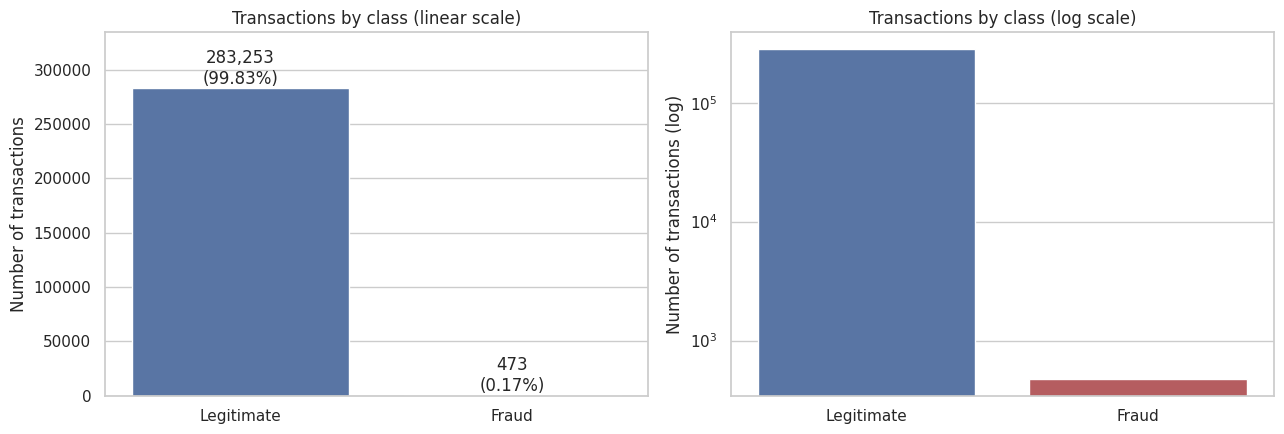

In [12]:
counts = transactions['Class'].map({0: 'Legitimate', 1: 'Fraud'}).value_counts()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=counts.index, y=counts.values, palette=CLASS_COLORS, ax=axes[0])
axes[0].set_title('Transactions by class (linear scale)')
axes[0].set_ylabel('Number of transactions')
axes[0].set_xlabel('')
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f'{v:,}\n({v / counts.sum():.2%})', ha='center', va='bottom')
axes[0].set_ylim(0, counts.max() * 1.18)

sns.barplot(x=counts.index, y=counts.values, palette=CLASS_COLORS, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Transactions by class (log scale)')
axes[1].set_ylabel('Number of transactions (log)')
axes[1].set_xlabel('')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/class_imbalance.png', bbox_inches='tight')
plt.show()

Only **0.167%** of transactions are fraud (≈1 in 600). A model that always predicts *legitimate* is 99.83% accurate yet catches no fraud — accuracy cannot be used.

### 5.2 Which features separate fraud from legitimate? (KS statistic)

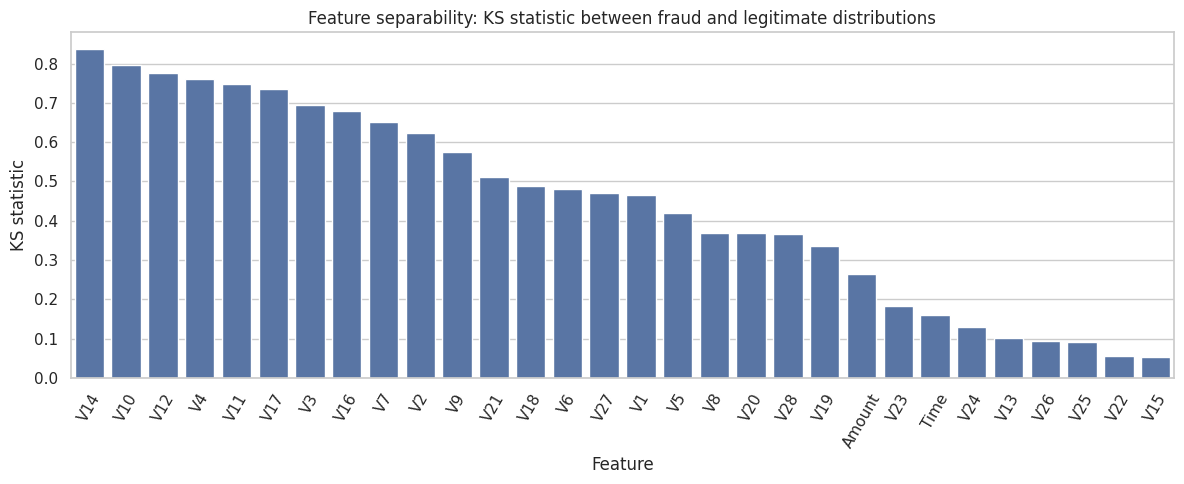

,KS
V14,0.838
V10,0.797
V12,0.777
V4,0.761
V11,0.747
V17,0.736
V3,0.695
V16,0.678


In [13]:
# Two-sample Kolmogorov-Smirnov statistic: 0 = identical distributions, 1 = perfectly separated
is_fraud = transactions['Class'] == 1
ks_scores = pd.Series({col: ks_2samp(transactions.loc[is_fraud, col],
                                     transactions.loc[~is_fraud, col]).statistic
                       for col in pca_cols + ['Amount', 'Time']}).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=ks_scores.index, y=ks_scores.values, color='#4C72B0', ax=ax)
ax.set_title('Feature separability: KS statistic between fraud and legitimate distributions')
ax.set_xlabel('Feature')
ax.set_ylabel('KS statistic')
ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/ks_feature_ranking.png', bbox_inches='tight')
plt.show()
ks_scores.head(8).round(3).to_frame('KS')

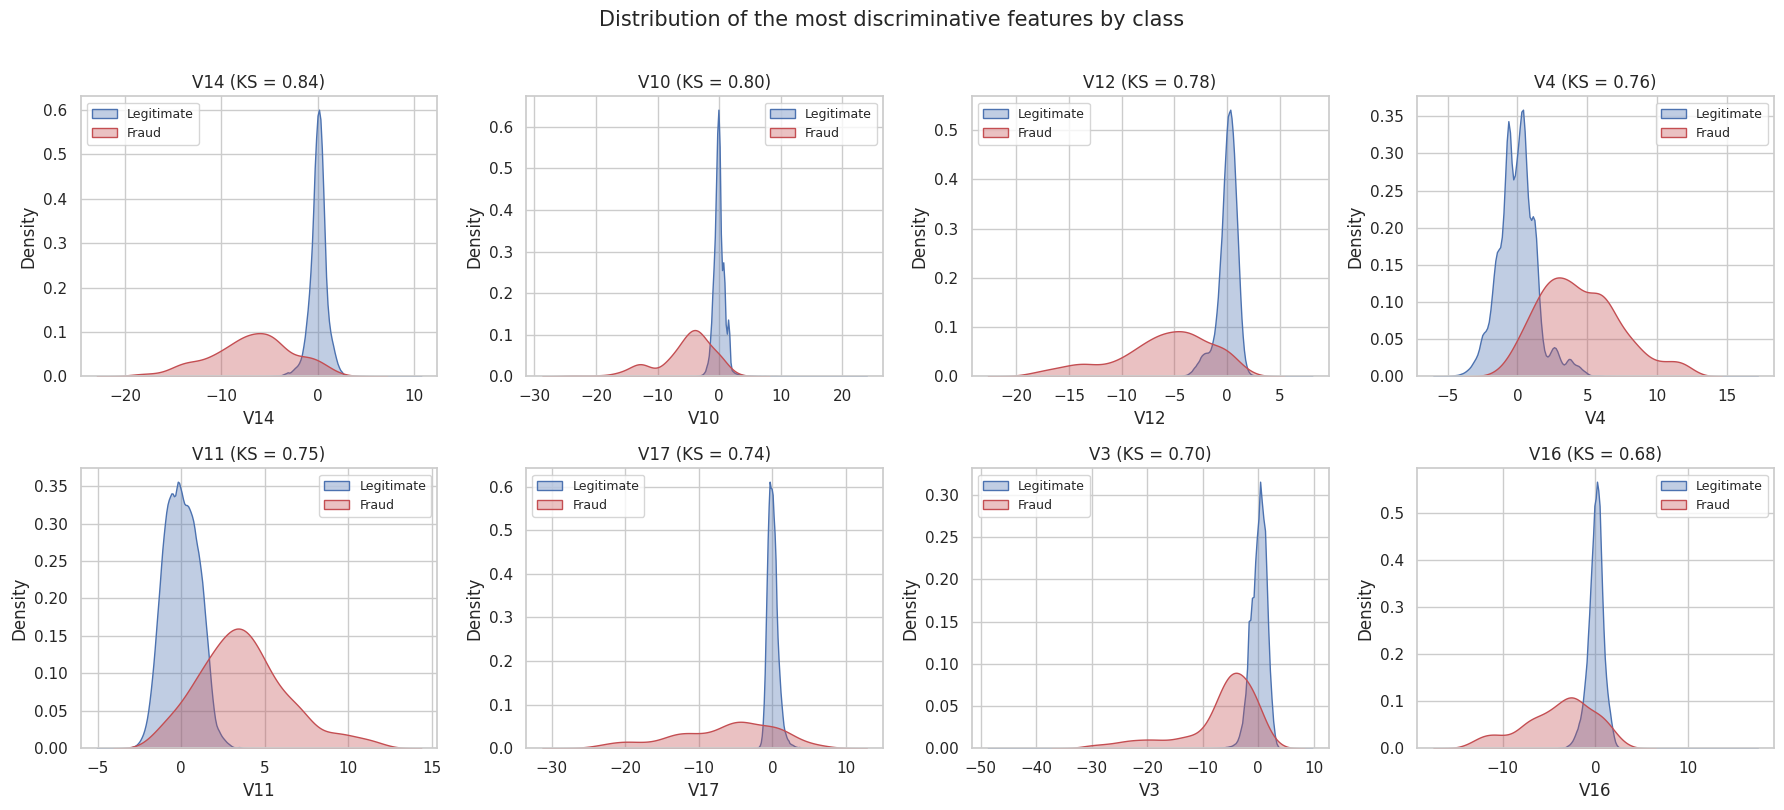

In [14]:
# Class-conditional density for the 8 most separating features
top_features = ks_scores.index[:8]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, top_features):
    for label, color in CLASS_COLORS.items():
        subset = transactions.loc[transactions['Class'] == (label == 'Fraud'), col]
        sns.kdeplot(subset, ax=ax, fill=True, alpha=0.35, color=color, label=label,
                    common_norm=False, warn_singular=False)
    ax.set_title(f'{col} (KS = {ks_scores[col]:.2f})')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
plt.suptitle('Distribution of the most discriminative features by class', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/top_feature_kde.png', bbox_inches='tight')
plt.show()

- **V14, V10, V12, V4, V11, V17, V3 and V16** separate the classes best (KS ≈ 0.6–0.9). This matches the expectation in the Module 16 problem statement (V14, V12, V10, V17).
- Fraud distributions are shifted and much wider — fraud sits in the tails of the legitimate distribution, consistent with the outlier analysis.
- `Amount` and `Time` on their own separate the classes only weakly.

### 5.3 Transaction amount

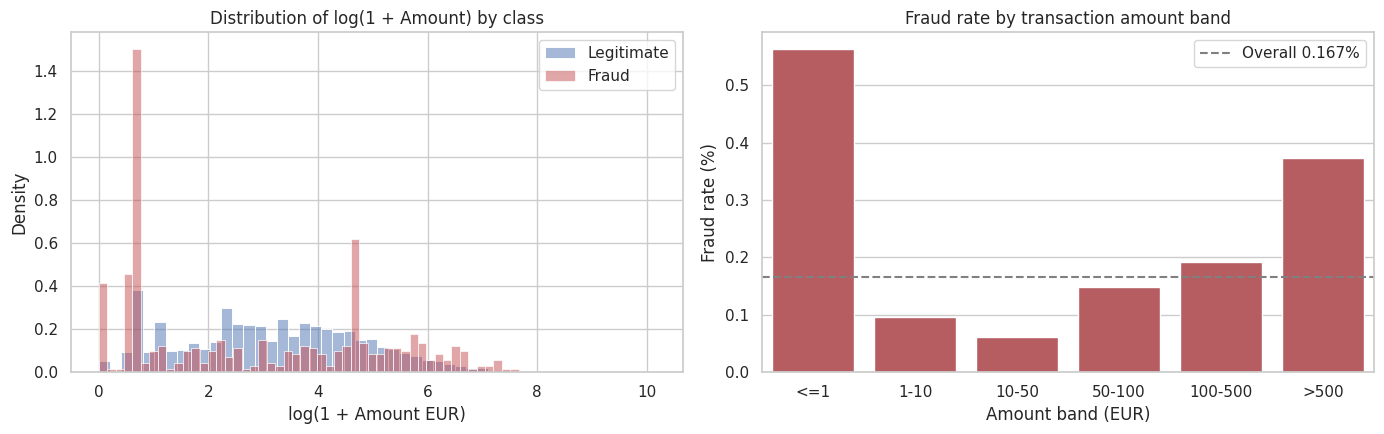

Class
Legitimate median    22.00
Fraud median          9.82
Name: Amount, dtype: float64


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for label, color in CLASS_COLORS.items():
    subset = transactions.loc[transactions['Class'] == (label == 'Fraud'), 'Amount']
    sns.histplot(np.log1p(subset), bins=50, stat='density', color=color, alpha=0.5,
                 label=label, ax=axes[0])
axes[0].set_title('Distribution of log(1 + Amount) by class')
axes[0].set_xlabel('log(1 + Amount EUR)')
axes[0].legend()

amount_bands = pd.cut(transactions['Amount'], bins=[-0.01, 1, 10, 50, 100, 500, 30000],
                      labels=['<=1', '1-10', '10-50', '50-100', '100-500', '>500'])
band_rate = transactions.groupby(amount_bands, observed=True)['Class'].mean() * 100
sns.barplot(x=band_rate.index.astype(str), y=band_rate.values, color='#C44E52', ax=axes[1])
axes[1].axhline(fraud_rate * 100, ls='--', color='grey', label=f'Overall {fraud_rate:.3%}')
axes[1].set_title('Fraud rate by transaction amount band')
axes[1].set_xlabel('Amount band (EUR)')
axes[1].set_ylabel('Fraud rate (%)')
axes[1].legend()
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/amount_analysis.png', bbox_inches='tight')
plt.show()
print(transactions.groupby('Class')['Amount'].median().rename({0: 'Legitimate median', 1: 'Fraud median'}))

- Fraud has a bimodal amount profile: many **very small "card-testing" transactions (≤ €1)** and a second group of larger purchases.
- The fraud rate is highest in the ≤ €1 band and the €100–€500+ bands, and lowest for everyday €10–€50 purchases.

### 5.4 Time of day

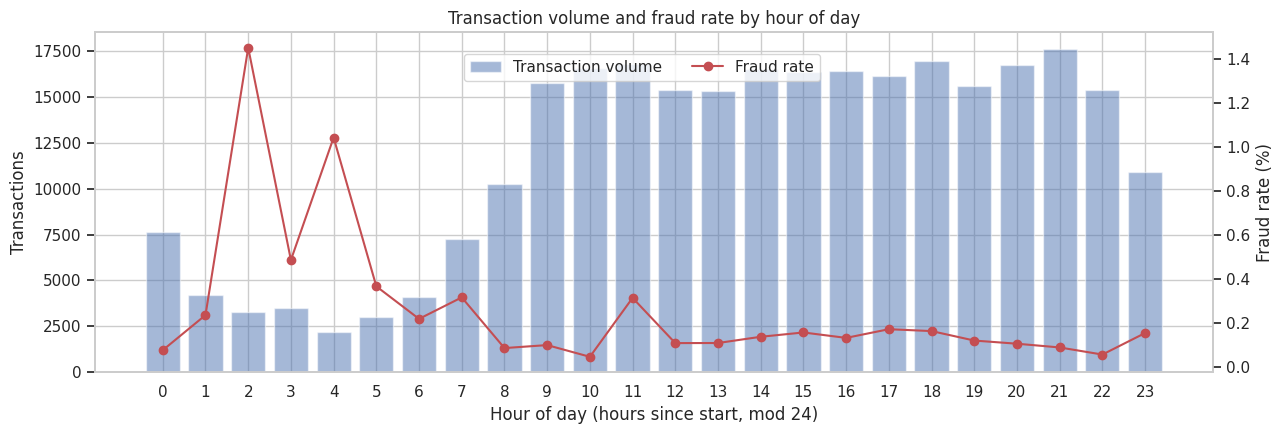

In [16]:
# Time is seconds from the first transaction; convert to hour-of-day (0-23)
hour_of_day = (transactions['Time'] // 3600) % 24
hourly = transactions.assign(hour=hour_of_day).groupby('hour').agg(
    transactions=('Class', 'size'), fraud_rate=('Class', 'mean'))

fig, ax1 = plt.subplots(figsize=(13, 4.5))
ax1.bar(hourly.index, hourly['transactions'], color='#4C72B0', alpha=0.5, label='Transaction volume')
ax1.set_xlabel('Hour of day (hours since start, mod 24)')
ax1.set_ylabel('Transactions')
ax2 = ax1.twinx()
ax2.plot(hourly.index, hourly['fraud_rate'] * 100, color='#C44E52', marker='o', label='Fraud rate')
ax2.set_ylabel('Fraud rate (%)')
ax2.grid(False)
ax1.set_xticks(range(24))
ax1.set_title('Transaction volume and fraud rate by hour of day')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.88), ncol=2)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/hourly_fraud_rate.png', bbox_inches='tight')
plt.show()

Legitimate volume collapses overnight (hours ~0–6) while fraud continues, so the **fraud rate spikes during low-activity night hours** (≈1.45% at hour 2 and ≈1.0% at hour 4, versus ≈0.1–0.2% through the day). Note the dataset does not state the clock time of `Time = 0`, so hours are relative to the start of the capture window. Hour of day is a useful engineered feature even though raw `Time` is not.

### 5.5 Correlations

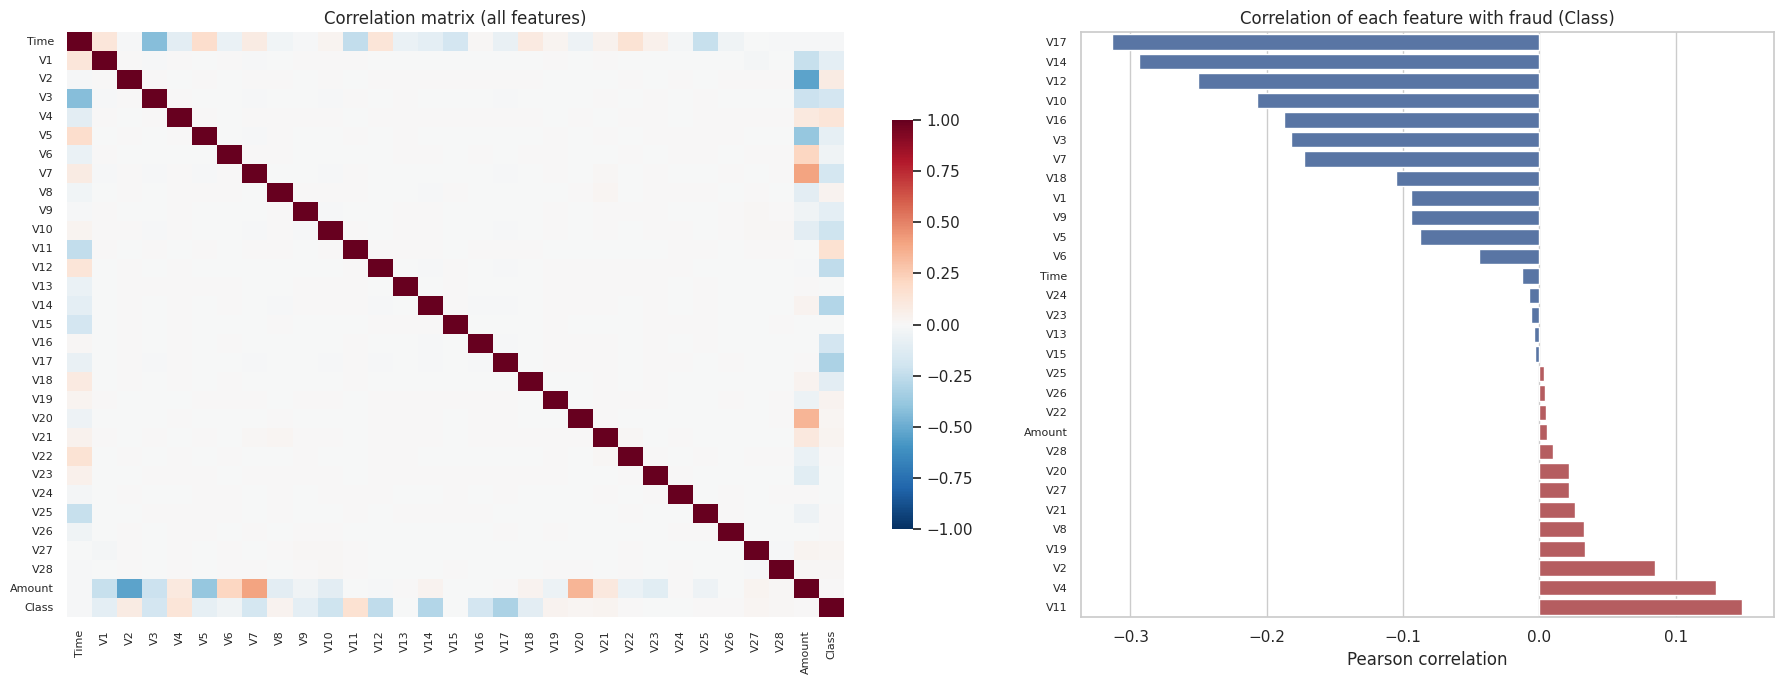

In [17]:
corr = transactions.corr()
fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1.4, 1]})
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=axes[0],
            cbar_kws={'shrink': 0.7}, xticklabels=True, yticklabels=True)
axes[0].set_title('Correlation matrix (all features)')
axes[0].tick_params(labelsize=8)

class_corr = corr['Class'].drop('Class').sort_values()
sns.barplot(x=class_corr.values, y=class_corr.index,
            palette=['#C44E52' if v > 0 else '#4C72B0' for v in class_corr.values], ax=axes[1])
axes[1].set_title('Correlation of each feature with fraud (Class)')
axes[1].set_xlabel('Pearson correlation')
axes[1].set_ylabel('')
axes[1].tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/correlations.png', bbox_inches='tight')
plt.show()

- The PCA components are mutually uncorrelated (by construction), so there is **no multicollinearity** among V1–V28 — good for linear models.
- `Amount` correlates with some components (e.g. V7, V20 positive; V2, V5 negative), which reflects how the PCA was built on the original features.
- Linear correlations with `Class` are small in absolute terms (strongest: V17, V14, V12, V10 negative; V11, V4 positive) because the target is so rare — the KS view above is a better guide to separability.

## 6. Feature engineering

In [18]:
transactions_fe = transactions.copy()

# Hour of day and a night-time flag (fraud rate peaks when legitimate volume is low)
transactions_fe['hour'] = (transactions_fe['Time'] // 3600) % 24
transactions_fe['is_night'] = transactions_fe['hour'].between(0, 6).astype(int)

# Log-transform the heavily skewed amount; flag micro 'card-testing' transactions
transactions_fe['log_amount'] = np.log1p(transactions_fe['Amount'])
transactions_fe['is_micro_amount'] = (transactions_fe['Amount'] <= 1).astype(int)

# Cyclical encoding so hour 23 and hour 0 are close to each other
transactions_fe['hour_sin'] = np.sin(2 * np.pi * transactions_fe['hour'] / 24)
transactions_fe['hour_cos'] = np.cos(2 * np.pi * transactions_fe['hour'] / 24)

# Raw Time (a running counter) and Amount are replaced by the engineered versions
transactions_fe = transactions_fe.drop(columns=['Time', 'Amount', 'hour'])

engineered = ['is_night', 'log_amount', 'is_micro_amount', 'hour_sin', 'hour_cos']
transactions_fe.groupby('Class')[engineered].mean().T.rename(columns={0: 'Legitimate', 1: 'Fraud'}).round(3)

Class,Legitimate,Fraud
is_night,0.098,0.262
log_amount,3.154,2.838
is_micro_amount,0.106,0.362
hour_sin,-0.245,-0.054
hour_cos,-0.175,-0.078


In [19]:
# Fraud-rate lift for the binary engineered flags
flag_lift = pd.DataFrame({
    flag: {'share_of_transactions': transactions_fe[flag].mean(),
           'fraud_rate_when_1': transactions_fe.loc[transactions_fe[flag] == 1, 'Class'].mean(),
           'fraud_rate_when_0': transactions_fe.loc[transactions_fe[flag] == 0, 'Class'].mean()}
    for flag in ['is_night', 'is_micro_amount']}).T
flag_lift['lift'] = flag_lift['fraud_rate_when_1'] / flag_lift['fraud_rate_when_0']
flag_lift.style.format({'share_of_transactions': '{:.1%}', 'fraud_rate_when_1': '{:.3%}',
                        'fraud_rate_when_0': '{:.3%}', 'lift': '{:.1f}x'})

,share_of_transactions,fraud_rate_when_1,fraud_rate_when_0,lift
is_night,9.8%,0.444%,0.136%,3.3x
is_micro_amount,10.7%,0.564%,0.119%,4.7x


Engineered features:
| Feature | Why |
|---|---|
| `log_amount` | Removes the extreme right skew of `Amount` so a linear model is not dominated by a few large values |
| `is_micro_amount` | Captures card-testing behaviour (≤ €1) — fraud rate several times the base rate |
| `is_night` | Flags hours 0–6 when fraud rate is several times the daytime rate |
| `hour_sin`, `hour_cos` | Cyclical hour encoding so 23:00 and 00:00 are neighbours |

`Time` (a running counter with no meaning outside this 2-day window) and raw `Amount` are dropped.

## 7. Baseline model
### 7.1 Evaluation metric and rationale
- **Primary metric: PR-AUC (average precision).** With 0.17% positives, ROC-AUC is inflated by the huge number of true negatives; PR-AUC focuses only on how well fraud is ranked and how precise the alerts are. A random model scores PR-AUC ≈ 0.0017 (the base rate), so the metric is very easy to interpret against that floor.
- **Secondary: F2-score** at the chosen threshold — weighs recall twice as much as precision, because a missed fraud is far more expensive than a false alert.
- **Business view: expected cost** using the cost matrix from the Module 16 problem statement — **FN = \$200** (average fraud loss) and **FP = \$5** (review cost / customer friction). The threshold that minimises cost on validation data is reported alongside the default 0.5.
- ROC-AUC is reported for completeness only.

### 7.2 Train/test split and preprocessing

In [20]:
target = 'Class'
X = transactions_fe.drop(columns=target)
y = transactions_fe[target]

# Stratified 80/20 split preserves the 0.17% fraud rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

# Scale continuous columns; leave 0/1 flags untouched
binary_cols = ['is_night', 'is_micro_amount']
scale_cols = [c for c in X.columns if c not in binary_cols]
preprocessor = ColumnTransformer([('scale', StandardScaler(), scale_cols)], remainder='passthrough')

print(f'Train: {X_train.shape[0]:,} rows ({y_train.sum()} fraud) | '
      f'Test: {X_test.shape[0]:,} rows ({y_test.sum()} fraud)')

Train: 226,980 rows (378 fraud) | Test: 56,746 rows (95 fraud)


### 7.3 Models: dummy classifier vs logistic regression

In [21]:
COST_FN, COST_FP = 200, 5  # dollars per missed fraud / per false alert

def evaluate(name, y_true, proba, threshold=0.5):
    """Return the metric set used throughout this project for one model/threshold."""
    preds = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    return {'model': name, 'threshold': threshold,
            'PR_AUC': average_precision_score(y_true, proba),
            'ROC_AUC': roc_auc_score(y_true, proba),
            'precision': precision_score(y_true, preds, zero_division=0),
            'recall': recall_score(y_true, preds),
            'F2': fbeta_score(y_true, preds, beta=2, zero_division=0),
            'TP': tp, 'FP': fp, 'FN': fn,
            'cost_$': fn * COST_FN + fp * COST_FP}

models = {
    'Dummy (always legitimate)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'Logistic Regression (balanced)': LogisticRegression(max_iter=2000, class_weight='balanced',
                                                         random_state=RANDOM_STATE),
}

fitted, results = {}, []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_pr_auc = {}
for name, clf in models.items():
    pipe = Pipeline([('prep', clone(preprocessor)), ('clf', clone(clf))])
    cv_pr_auc[name] = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='average_precision').mean()
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    results.append(evaluate(name, y_test, pipe.predict_proba(X_test)[:, 1]))

results_df = pd.DataFrame(results).set_index('model')
results_df.insert(1, 'CV_PR_AUC', pd.Series(cv_pr_auc))
results_df.round(3)

,threshold,CV_PR_AUC,PR_AUC,ROC_AUC,precision,recall,F2,TP,FP,FN,cost_$
model,,,,,,,,,,,
Dummy (always legitimate),0.5,0.002,0.002,0.500,0.000,0.000,0.000,0,0,95,19000
Logistic Regression,0.5,0.756,0.695,0.953,0.864,0.600,0.639,57,9,38,7645
Logistic Regression (balanced),0.5,0.756,0.679,0.966,0.055,0.874,0.220,83,1420,12,9500


### 7.4 Cost-optimal decision threshold

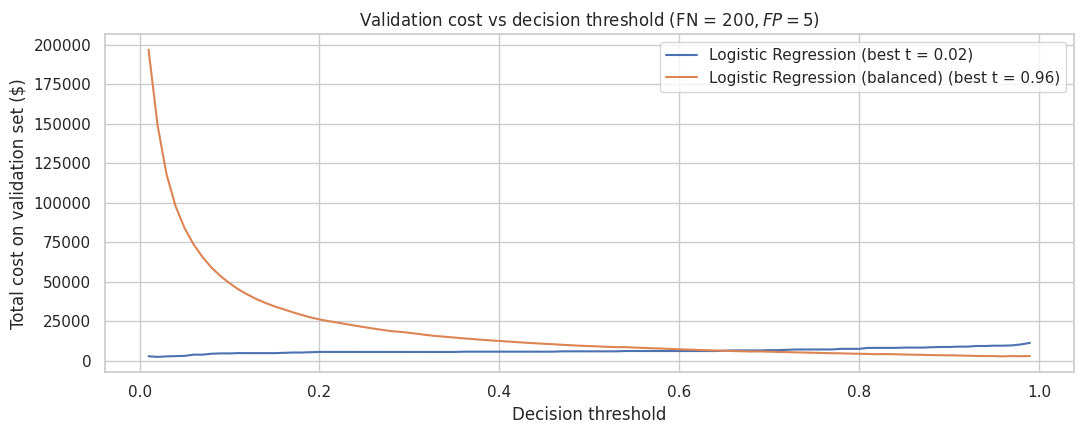

{'Logistic Regression': np.float64(0.02),
 'Logistic Regression (balanced)': np.float64(0.96)}

In [22]:
# Choose the threshold on a validation split carved from TRAINING data (no test leakage)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.25,
                                            stratify=y_train, random_state=RANDOM_STATE)
thresholds = np.linspace(0.01, 0.99, 99)
cost_curves = {}
for name in ['Logistic Regression', 'Logistic Regression (balanced)']:
    # clone() so the fully-trained models in `fitted` are not overwritten
    pipe = Pipeline([('prep', clone(preprocessor)), ('clf', clone(models[name]))]).fit(X_tr, y_tr)
    val_proba = pipe.predict_proba(X_val)[:, 1]
    cost_curves[name] = pd.Series(
        [evaluate(name, y_val, val_proba, t)['cost_$'] for t in thresholds], index=thresholds)

best_thresholds = {name: curve.idxmin() for name, curve in cost_curves.items()}

fig, ax = plt.subplots(figsize=(11, 4.5))
for name, curve in cost_curves.items():
    ax.plot(curve.index, curve.values, label=f'{name} (best t = {best_thresholds[name]:.2f})')
ax.set_title(f'Validation cost vs decision threshold (FN = ${COST_FN}, FP = ${COST_FP})')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Total cost on validation set ($)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/cost_vs_threshold.png', bbox_inches='tight')
plt.show()
{k: round(v, 2) for k, v in best_thresholds.items()}

In [23]:
# Re-evaluate both logistic models on the untouched TEST set at their cost-optimal thresholds
tuned = [evaluate(f'{name} @ t={t:.2f}', y_test, fitted[name].predict_proba(X_test)[:, 1], t)
         for name, t in best_thresholds.items()]
comparison = pd.concat([results_df.drop(columns='CV_PR_AUC'), pd.DataFrame(tuned).set_index('model')])
comparison.round(3)

,threshold,PR_AUC,ROC_AUC,precision,recall,F2,TP,FP,FN,cost_$
model,,,,,,,,,,
Dummy (always legitimate),0.50,0.002,0.500,0.000,0.000,0.000,0,0,95,19000
Logistic Regression,0.50,0.695,0.953,0.864,0.600,0.639,57,9,38,7645
Logistic Regression (balanced),0.50,0.679,0.966,0.055,0.874,0.220,83,1420,12,9500
Logistic Regression @ t=0.02,0.02,0.695,0.953,0.586,0.789,0.738,75,53,20,4265
Logistic Regression (balanced) @ t=0.96,0.96,0.679,0.966,0.469,0.800,0.701,76,86,19,4230


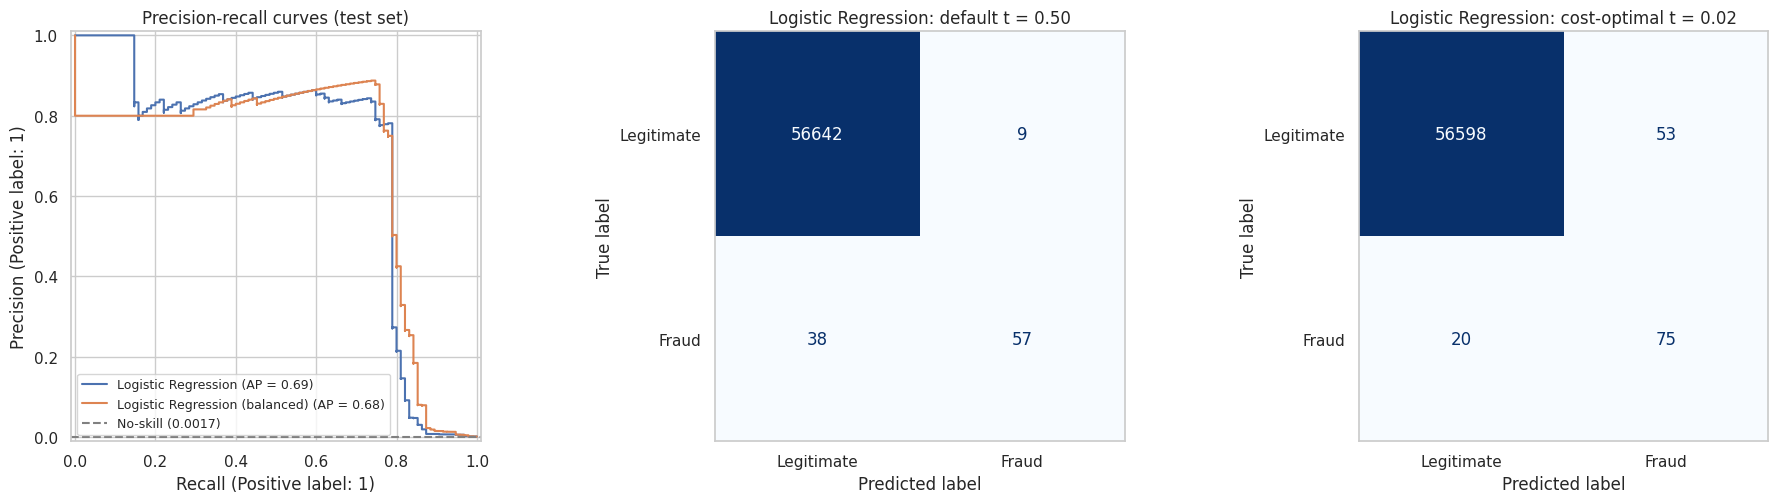

In [24]:
baseline_name = 'Logistic Regression'
baseline = fitted[baseline_name]
t_star = best_thresholds[baseline_name]
test_proba = baseline.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))
for name in ['Logistic Regression', 'Logistic Regression (balanced)']:
    PrecisionRecallDisplay.from_estimator(fitted[name], X_test, y_test, ax=axes[0], name=name)
axes[0].axhline(y_test.mean(), ls='--', color='grey', label=f'No-skill ({y_test.mean():.4f})')
axes[0].set_title('Precision-recall curves (test set)')
axes[0].legend(loc='lower left', fontsize=9)

for ax, t, title in [(axes[1], 0.5, 'default t = 0.50'), (axes[2], t_star, f'cost-optimal t = {t_star:.2f}')]:
    ConfusionMatrixDisplay.from_predictions(y_test, (test_proba >= t).astype(int),
                                            display_labels=['Legitimate', 'Fraud'],
                                            cmap='Blues', colorbar=False, ax=ax)
    ax.set_title(f'{baseline_name}: {title}')
    ax.grid(False)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/baseline_evaluation.png', bbox_inches='tight')
plt.show()

### 7.5 What drives the baseline?

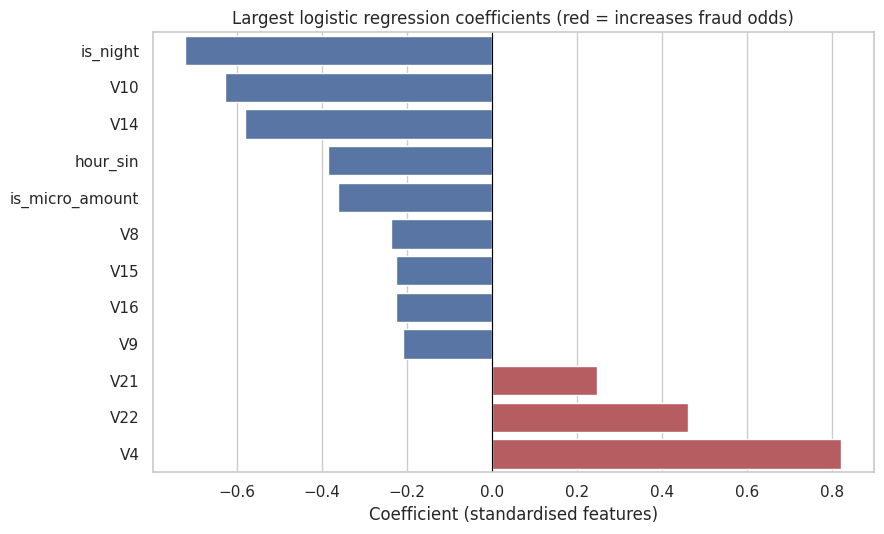

In [25]:
coef_names = [n.split('__')[-1] for n in baseline.named_steps['prep'].get_feature_names_out()]
coefs = pd.Series(baseline.named_steps['clf'].coef_[0], index=coef_names)
top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index[:12]).sort_values()

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(x=top_coefs.values, y=top_coefs.index,
            palette=['#C44E52' if v > 0 else '#4C72B0' for v in top_coefs.values], ax=ax)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Largest logistic regression coefficients (red = increases fraud odds)')
ax.set_xlabel('Coefficient (standardised features)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/baseline_coefficients.png', bbox_inches='tight')
plt.show()

In [26]:
# Key numbers quoted in the interpretation and README
row = comparison.loc[f'{baseline_name} @ t={t_star:.2f}']
default = comparison.loc[baseline_name]
dummy = comparison.loc['Dummy (always legitimate)']
print(f"Baseline PR-AUC {row['PR_AUC']:.3f} | ROC-AUC {row['ROC_AUC']:.3f}")
print(f"t=0.50  -> recall {default['recall']:.1%}, precision {default['precision']:.1%}, cost ${default['cost_$']:,.0f}")
print(f"t={t_star:.2f} -> recall {row['recall']:.1%}, precision {row['precision']:.1%}, "
      f"F2 {row['F2']:.3f}, cost ${row['cost_$']:,.0f}")
print(f"Dummy cost ${dummy['cost_$']:,.0f} -> saving vs dummy ${dummy['cost_$'] - row['cost_$']:,.0f}")

Baseline PR-AUC 0.695 | ROC-AUC 0.953
t=0.50  -> recall 60.0%, precision 86.4%, cost $7,645
t=0.02 -> recall 78.9%, precision 58.6%, F2 0.738, cost $4,265
Dummy cost $19,000 -> saving vs dummy $14,735


### 7.6 Interpreting the baseline
- The **dummy classifier** is 99.8% accurate but catches **zero** fraud and costs the most — confirming accuracy is meaningless here and that cost/PR-AUC are the right lenses.
- **Logistic regression** reaches a PR-AUC of roughly **0.7** against a no-skill floor of 0.0017, i.e. it ranks fraud far above chance.
- At the default 0.5 threshold it is precise but misses a large share of fraud. Lowering the threshold to the **cost-optimal value** found on validation data catches more fraud and **reduces total cost**, because each missed fraud (\$200) costs 40× a false alert (\$5).
- `class_weight='balanced'` at the default threshold gives high recall (87%) but floods the review queue (1,420 false alerts, 5.5% precision). Once each model's threshold is tuned, the two converge to a similar cost (≈\$4.2k–\$4.3k); the simpler **unweighted logistic regression at its cost-optimal threshold is the baseline to beat in Module 24**.
- The largest coefficients (V4, V10, V14, V22) agree with the KS ranking from the EDA. `is_night` and `is_micro_amount` receive *negative* weights once the V-components are in the model — the components already encode that risk, so these flags mainly correct for it. Tree-based models in Module 24 will show whether they add value non-linearly.

## 8. Summary of findings and next steps
**Findings**
1. The dataset has no missing values; 1,081 duplicate rows were removed, leaving 283,726 transactions with 473 frauds (0.167%).
2. Outliers carry most of the fraud signal and were deliberately retained.
3. V14, V10, V12, V4, V11 and V17 are the most discriminative features; fraud is concentrated in micro (≤ €1) amounts and in night-time hours.
4. A logistic regression baseline achieves PR-AUC ≈ 0.7; tuning the decision threshold for the \$200/\$5 cost matrix gives a meaningful cost reduction over the default threshold.

**Next steps (Module 24)**
- Compare k-NN, Decision Tree, SVM-RBF, Random Forest and XGBoost (`scale_pos_weight`) using `GridSearchCV` with PR-AUC scoring.
- Test resampling (RandomUnderSampler, SMOTE, ADASYN) inside `imblearn` pipelines so resampling happens only on training folds.
- Re-run cost-optimal threshold tuning for each model and report savings on the test set.
- Produce a model card and a plain-English threshold recommendation for non-technical stakeholders.